# Image-quality screen — v13 findings

What the screen does, measured on 450 images. Run on the PROD box 2026-09-12
against `quality_20260912`, prompt variant `quality_screen_v13`, 2×L4.

v13 is v12 plus one question — **COMPOSITION**, how many documents are in the
picture — because taxpayers photograph several receipts at once and extraction
handles those badly. Everything below follows from that one addition.

**The headline:** on the decision the pipeline actually makes — send this image
on to extraction, or send it back for re-capture — the screen scores
**precision 0.991, recall 0.979, F1 0.985**, and passes no heavily degraded
image at all.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# Ordered worst-to-best so every severity axis in this notebook reads the same
# way round. A matrix that flips orientation between figures is read wrong.
LEVELS = ["GOOD", "FAIR", "POOR"]
COMPOSITIONS = ["SINGLE", "MULTIPLE"]

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

## Where these numbers come from

Set `REPORT_PATH` to the `quality_screen_report.json` you want to read. After a
production run that is `<output>/evaluation/quality_screen_report.json`.

It ships pointing at `notebooks/reports/quality_screen_report.json` — the
2026-09-12 PROD figures, transcribed from that run's printed report, so this
notebook renders before you have a report of your own to point it at. That file
carries an underscored `_transcription` key, and the notebook prints a NOTE when
it finds one, because a file with that name is otherwise indistinguishable from
one the pipeline wrote. A real report has no such key and gets no note.

`REPORT_PATH = None` uses the same numbers embedded in the data cell below.

A path that is set but unreadable is a hard failure, not a quiet return to the
embedded copy. Whichever source is used is printed in the output.

This notebook reads nothing but the report file — no pipeline config, no
`entrypoint.sh` — and writes only into `notebooks/figures/`. Running it changes
nothing a production run depends on, and nothing in the pipeline was changed to
support it.

In [2]:
# The report to chart. This one line is the only thing that changes between
# reading a production run and reading the transcription shipped beside this
# notebook -- so it is a plain path, edited by hand, not a value derived from
# pipeline config. Nothing here reads run_config.yml: this notebook is run by
# a person who knows where their run wrote, after that run has finished.
#
# After a production run, the report is at:
#   <output>/evaluation/quality_screen_report.json
# e.g. /home/jovyan/evaluation_data/quality_20260912/output/evaluation/quality_screen_report.json
REPORT_PATH: Path | None = REPO / "notebooks" / "reports" / "quality_screen_report.json"

# Exports land beside this notebook. notebooks/figures/*.svg is tracked on
# purpose -- the SVGs go into slides and git can diff them; the PNGs are not.
FIGURES = REPO / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)


def save(fig, name: str) -> None:
    """Write a figure as both SVG and PNG.

    Args:
        fig: The matplotlib figure to write.
        name: Basename without extension.
    """
    for suffix in ("svg", "png"):
        fig.savefig(FIGURES / f"{name}.{suffix}")

In [3]:
# ---------------------------------------------------------------------------
# Transcribed from the printed report of the PROD run, 2026-09-12 14:23, in the
# schema stages/evaluate_quality_screen.py:build_report writes. This is also
# what reports/quality_screen_report.json is generated from, so the two cannot
# drift. Rates carried alongside the counts are the printed 3dp values; the
# reconciliation cell recomputes them from the counts and fails if the two
# disagree, so a typo here cannot survive.
# ---------------------------------------------------------------------------
V13 = {
    "variant": "quality_screen_v13",
    # NOT a field the pipeline writes. Underscored so it cannot be mistaken for
    # one, and present because a file named quality_screen_report.json is
    # otherwise indistinguishable from one the evaluate stage produced.
    "_transcription": {
        "from": "the printed report of the PROD run of 2026-09-12 14:23:03",
        "corpus": (
            "not stated by that report. Its log named only the output directory, "
            "/home/jovyan/evaluation_data/quality_20260912/output."
        ),
    },
    "counts": {"total": 450, "scored": 450, "malformed": 0, "missing": 0, "think_drift": 0},
    "per_criterion": {
        "blur":    {"precision": 0.571, "recall": 1.000, "f1": 0.727,
                    "true_positives": 257, "false_positives": 193, "false_negatives": 0},
        "shadow":  {"precision": 1.000, "recall": 0.377, "f1": 0.547,
                    "true_positives": 113, "false_positives": 0, "false_negatives": 187},
        "crease":  {"precision": 0.500, "recall": 0.007, "f1": 0.013,
                    "true_positives": 1, "false_positives": 1, "false_negatives": 149},
        "faded":   {"precision": 0.985, "recall": 0.663, "f1": 0.793,
                    "true_positives": 199, "false_positives": 3, "false_negatives": 101},
        "tilt":    {"precision": 0.572, "recall": 1.000, "f1": 0.728,
                    "true_positives": 231, "false_positives": 173, "false_negatives": 0},
        "speckle": {"precision": 0.609, "recall": 0.866, "f1": 0.715,
                    "true_positives": 246, "false_positives": 158, "false_negatives": 38},
    },
    # The printed per-document-type block carries rates only, no counts.
    "by_document_type": {
        "invoice": {
            "blur":    {"precision": 0.667, "recall": 1.000, "f1": 0.800},
            "shadow":  {"precision": 1.000, "recall": 1.000, "f1": 1.000},
            "crease":  {"precision": None, "recall": 0.000, "f1": None},
            "faded":   {"precision": 1.000, "recall": 0.873, "f1": 0.932},
            "tilt":    {"precision": 0.513, "recall": 1.000, "f1": 0.678},
            "speckle": {"precision": 0.644, "recall": 0.773, "f1": 0.702},
        },
        "receipt": {
            "blur":    {"precision": 0.516, "recall": 1.000, "f1": 0.681},
            "shadow":  {"precision": 1.000, "recall": 0.016, "f1": 0.031},
            "crease":  {"precision": 0.500, "recall": 0.011, "f1": 0.021},
            "faded":   {"precision": 0.972, "recall": 0.542, "f1": 0.696},
            "tilt":    {"precision": 0.596, "recall": 1.000, "f1": 0.747},
            "speckle": {"precision": 0.592, "recall": 0.925, "f1": 0.722},
        },
    },
    "overall_confusion": {
        "FAIR->FAIR": 95, "FAIR->GOOD": 7, "FAIR->POOR": 48,
        "GOOD->FAIR": 2, "GOOD->GOOD": 117, "GOOD->POOR": 31,
        "POOR->FAIR": 40, "POOR->POOR": 110,
    },
    "severity_by_composition": {
        "MULTIPLE": {"FAIR->FAIR": 3, "FAIR->POOR": 27,
                     "GOOD->FAIR": 1, "GOOD->POOR": 29, "POOR->POOR": 30},
        "SINGLE": {"FAIR->FAIR": 92, "FAIR->GOOD": 7, "FAIR->POOR": 21,
                   "GOOD->FAIR": 1, "GOOD->GOOD": 117, "GOOD->POOR": 2,
                   "POOR->FAIR": 40, "POOR->POOR": 80},
    },
    "composition_tally": {"MULTIPLE": 94, "SINGLE": 356},
    "composition": {
        "labelled": 450, "scored": 450, "correct": 446, "accuracy": 0.991,
        "confusion": {"MULTIPLE->MULTIPLE": 90, "SINGLE->MULTIPLE": 4, "SINGLE->SINGLE": 356},
        "misses": [
            {"filename": "FOLDED003_receipt_heavy.png", "truth": "SINGLE", "predicted": "MULTIPLE"},
            {"filename": "FOLDED008_receipt_moderate.png", "truth": "SINGLE", "predicted": "MULTIPLE"},
            {"filename": "FOLDED021_receipt_heavy.png", "truth": "SINGLE", "predicted": "MULTIPLE"},
            {"filename": "FOLDED027_receipt_heavy.png", "truth": "SINGLE", "predicted": "MULTIPLE"},
        ],
    },
    "routing": {
        "scored": 450, "pass_levels": ["GOOD"], "multiple_documents": "reject",
        "sent_back_correctly": 323, "sent_back_wrongly": 3,
        "passed_correctly": 117, "passed_wrongly": 7,
        "precision": 0.991, "recall": 0.979, "f1": 0.985,
    },
}

# The v12 run on the SAME corpus and box, 2026-09-12 13:30. It has no
# composition or routing block: v12 never asks the question, so the scorer has
# no axis to apply the gate on and writes None rather than a number computed
# from half the rule.
V12 = {
    "variant": "quality_screen_v12",
    "counts": {"total": 450, "scored": 450, "malformed": 0, "missing": 0, "think_drift": 0},
    "per_criterion": {
        "blur":    {"precision": 0.571, "recall": 1.000, "f1": 0.727,
                    "true_positives": 257, "false_positives": 193, "false_negatives": 0},
        "shadow":  {"precision": 1.000, "recall": 0.377, "f1": 0.547,
                    "true_positives": 113, "false_positives": 0, "false_negatives": 187},
        "crease":  {"precision": 0.400, "recall": 0.027, "f1": 0.050,
                    "true_positives": 4, "false_positives": 6, "false_negatives": 146},
        "faded":   {"precision": 0.876, "recall": 0.850, "f1": 0.863,
                    "true_positives": 255, "false_positives": 36, "false_negatives": 45},
        "tilt":    {"precision": 0.582, "recall": 1.000, "f1": 0.736,
                    "true_positives": 231, "false_positives": 166, "false_negatives": 0},
        "speckle": {"precision": 0.676, "recall": 0.866, "f1": 0.759,
                    "true_positives": 246, "false_positives": 118, "false_negatives": 38},
    },
    "by_document_type": {
        "invoice": {
            "blur":    {"precision": 0.667, "recall": 1.000, "f1": 0.800},
            "shadow":  {"precision": 1.000, "recall": 1.000, "f1": 1.000},
            "crease":  {"precision": None, "recall": 0.000, "f1": None},
            "faded":   {"precision": 0.990, "recall": 0.918, "f1": 0.953},
            "tilt":    {"precision": 0.545, "recall": 1.000, "f1": 0.705},
            "speckle": {"precision": 0.914, "recall": 0.773, "f1": 0.837},
        },
        "receipt": {
            "blur":    {"precision": 0.516, "recall": 1.000, "f1": 0.681},
            "shadow":  {"precision": 1.000, "recall": 0.016, "f1": 0.031},
            "crease":  {"precision": 0.400, "recall": 0.042, "f1": 0.076},
            "faded":   {"precision": 0.815, "recall": 0.811, "f1": 0.813},
            "tilt":    {"precision": 0.596, "recall": 1.000, "f1": 0.747},
            "speckle": {"precision": 0.594, "recall": 0.925, "f1": 0.724},
        },
    },
    "overall_confusion": {
        "FAIR->FAIR": 48, "FAIR->GOOD": 6, "FAIR->POOR": 96,
        "GOOD->FAIR": 8, "GOOD->GOOD": 104, "GOOD->POOR": 38,
        "POOR->FAIR": 26, "POOR->POOR": 124,
    },
    "severity_by_composition": None,
    "composition_tally": {},
    "composition": None,
    "routing": None,
}

# The reference measurement already recorded in the repo, for comparison only:
# IMAGE_QUALITY_SCREEN.md:75 and config/run_config.yml:245, taken on the local
# 450-image corpus quality_20260911.
RECORDED = {
    "source": "IMAGE_QUALITY_SCREEN.md, quality_20260911",
    "precision": 0.997, "recall": 0.967, "f1": 0.982,
    "sent_back_correctly": 319, "sent_back_wrongly": 1,
}

In [4]:
_REQUIRED = ("counts", "per_criterion", "by_document_type", "overall_confusion")


def load_report(path: Path | None) -> dict:
    """Load the report to chart, saying out loud which source was used.

    Args:
        path: A quality_screen_report.json, or None for the embedded figures.

    Returns:
        A report dict in build_report's schema.

    Raises:
        FileNotFoundError: The path was set but no file is there.
        KeyError: The file is JSON but not a quality-screen report.
    """
    if path is None:
        print("SOURCE: embedded figures — PROD run 2026-09-12, quality_screen_v13.")
        print("        Set REPORT_PATH to a quality_screen_report.json to re-render.")
        return V13

    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(
            f"No report at {path}.\n"
            f"  What:       REPORT_PATH names a file that does not exist.\n"
            f"  Where:      the REPORT_PATH constant in the cell above.\n"
            f"  Expected:   the quality_screen_report.json written by KFP_TASK=evaluate,\n"
            f"              e.g. <output>/evaluation/quality_screen_report.json\n"
            f"  How to fix: copy that file down from the box, or set REPORT_PATH = None\n"
            f"              to chart the embedded 2026-09-12 figures instead."
        )

    report = json.loads(path.read_text())
    missing = [key for key in _REQUIRED if key not in report]
    if missing:
        raise KeyError(
            f"{path} is not a quality-screen report.\n"
            f"  What:       missing top-level key(s): {', '.join(missing)}.\n"
            f"  Where:      {path}\n"
            f"  Expected:   the keys build_report writes: {', '.join(_REQUIRED)}\n"
            f"  How to fix: point REPORT_PATH at quality_screen_report.json, not at\n"
            f"              quality_screen.jsonl (the per-image records)."
        )
    print(f"SOURCE: {path}  (variant {report.get('variant', '<unrecorded>')})")
    describe(report)
    return report


def describe(report: dict) -> None:
    """Flag a hand-transcribed report as one, and say nothing for a real one.

    A report the pipeline wrote needs no announcement: it is what it says it is.
    The transcription does, because the numbers are identical and the file name
    is the same.
    """
    transcription = report.get("_transcription")
    if not transcription:
        return
    print("NOTE: transcribed by hand, not written by the evaluate stage.")
    for key, value in transcription.items():
        print(f"      {key}: {value}")


report = load_report(REPORT_PATH)

SOURCE: /Users/tod/Desktop/LMM_POC/notebooks/reports/quality_screen_report.json  (variant quality_screen_v13)
NOTE: transcribed by hand, not written by the evaluate stage.
      from: the printed report of the PROD run of 2026-09-12 14:23:03
      corpus: not stated by that report. Its log named only the output directory, /home/jovyan/evaluation_data/quality_20260912/output.
      written_by: scratchpad/build_v13_notebook.py, from the notebook's own data cell
      by_document_type: Rates only. The printed per-document-type block carries no TP/FP/FN, where a report written by the stage would.


### Reconciling the transcription

The embedded figures were read off a printed report, so the notebook checks
them against each other before it charts anything. Every one of these has to
hold for the numbers to be internally consistent, and each fails loudly rather
than quietly drawing a wrong bar:

1. rates recomputed from the counts match the printed rates
2. the severity matrix sums to 450, and to 150 per truth level
3. the two composition sub-matrices sum, cell by cell, to the overall one
4. the routing counts are derivable from severity and composition together —
   this is the real check, because it is the only one that crosses the two axes

In [5]:
def check(condition: bool, message: str) -> None:
    """Assert a reconciliation, naming what failed."""
    if not condition:
        raise AssertionError(f"Transcription does not reconcile: {message}")


# 1. Rates against counts.
for name, values in report["per_criterion"].items():
    tp = values["true_positives"]
    fp = values["false_positives"]
    fn = values["false_negatives"]
    if tp + fp:
        check(abs(tp / (tp + fp) - values["precision"]) < 0.001, f"{name} precision")
    if tp + fn:
        check(abs(tp / (tp + fn) - values["recall"]) < 0.001, f"{name} recall")

# 2. Severity totals.
confusion = report["overall_confusion"]
check(sum(confusion.values()) == report["counts"]["total"], "severity matrix total")
for level in LEVELS:
    truth_total = sum(v for k, v in confusion.items() if k.split("->")[0] == level)
    check(truth_total == 150, f"{level} truth count is {truth_total}, expected 150")

# 3. The split sums back to the whole.
split = report["severity_by_composition"]
if split:
    recombined: dict[str, int] = {}
    for matrix in split.values():
        for key, count in matrix.items():
            recombined[key] = recombined.get(key, 0) + count
    check(recombined == confusion, "split by composition does not sum to the overall matrix")

# 4. Routing, derived from the other two axes.
routing = report["routing"]
if routing and split:
    # An image is sent back when its severity fails the gate OR it is a collage.
    usable = sum(v for k, v in split["SINGLE"].items() if k.split("->")[0] in routing["pass_levels"])
    check(
        usable == routing["passed_correctly"] + routing["sent_back_wrongly"],
        f"{usable} genuinely usable images, but routing accounts for "
        f"{routing['passed_correctly'] + routing['sent_back_wrongly']}",
    )
    # Passed wrongly = an unusable image the model graded into a passing level.
    passed_wrongly = sum(
        v
        for k, v in split["SINGLE"].items()
        if k.split("->")[0] not in routing["pass_levels"] and k.split("->")[1] in routing["pass_levels"]
    )
    check(passed_wrongly == routing["passed_wrongly"], "passed-wrongly count")
    total = sum(routing[k] for k in
                ("sent_back_correctly", "sent_back_wrongly", "passed_correctly", "passed_wrongly"))
    check(total == report["counts"]["total"], "routing counts do not sum to the corpus")

print("All reconciliations hold.")

All reconciliations hold.


## 1. The gate — the only number that describes the product

`pass_levels: [GOOD]`, `multiple_documents: reject`. Anything not graded GOOD
is sent back, and **every** collage is sent back however good the photograph is,
because downstream extraction cannot read a plate of four receipts reliably
whether or not the picture is any good.

"Sent back" is the positive class: precision is how often a return was
justified, recall is how much of the unusable pile we caught.

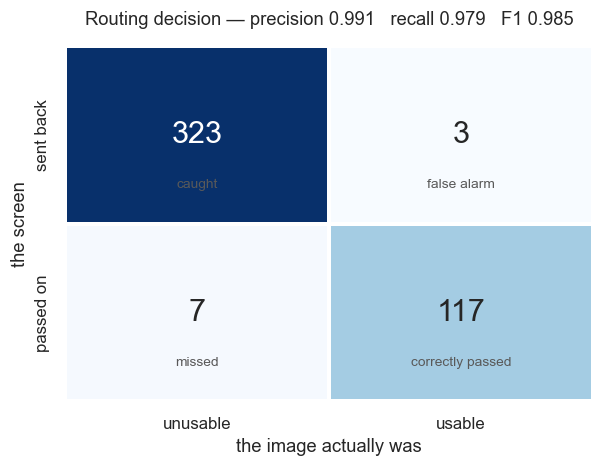

Recorded reference (IMAGE_QUALITY_SCREEN.md, quality_20260911): precision 0.997, recall 0.967, F1 0.982


In [6]:
routing = report["routing"]

matrix = pd.DataFrame(
    [[routing["sent_back_correctly"], routing["sent_back_wrongly"]],
     [routing["passed_wrongly"], routing["passed_correctly"]]],
    index=["sent back", "passed on"],
    columns=["unusable", "usable"],
)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
sns.heatmap(
    matrix, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1.5, linecolor="white",
    annot_kws={"size": 20}, ax=ax,
)
ax.set_xlabel("the image actually was")
ax.set_ylabel("the screen")
ax.set_title(
    f"Routing decision — precision {routing['precision']:.3f}   "
    f"recall {routing['recall']:.3f}   F1 {routing['f1']:.3f}",
    pad=14,
)
# Name what each cell costs, since the two errors are not interchangeable: a
# false alarm asks a taxpayer to re-photograph something that was fine, a miss
# sends an unreadable image on to extraction.
for (row, col), note in {
    (0, 0): "caught", (0, 1): "false alarm",
    (1, 0): "missed", (1, 1): "correctly passed",
}.items():
    ax.text(col + 0.5, row + 0.78, note, ha="center", va="center", fontsize=9, color="0.35")

save(fig, "v13_routing_gate")
plt.show()

print(f"Recorded reference ({RECORDED['source']}): "
      f"precision {RECORDED['precision']}, recall {RECORDED['recall']}, F1 {RECORDED['f1']}")

The recorded reference on the sibling corpus was 0.997 / 0.967 / 0.982. This run
lands at 0.991 / 0.979 / 0.985 — two extra false alarms bought four more
catches. The reproduction holds.

**No heavily degraded image was passed.** There is no `POOR->GOOD` cell in the
severity matrix below; all seven misses are `FAIR->GOOD`, i.e. moderately
degraded images called good.

## 2. Composition — the question v13 adds

Every collage in the corpus was found. The only four errors run the other way:
single receipts called MULTIPLE.

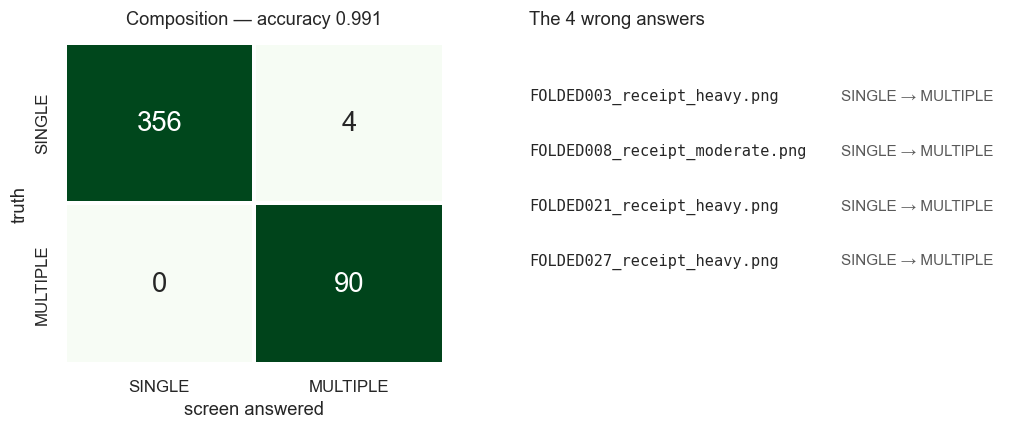

In [7]:
composition = report["composition"]

grid = pd.DataFrame(0, index=COMPOSITIONS, columns=COMPOSITIONS)
for key, count in composition["confusion"].items():
    truth, predicted = key.split("->")
    grid.loc[truth, predicted] = count

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.25]})

# Coloured by share of the truth row, annotated with the counts. A shared count
# scale would paint the 90-of-90 collage row pale beside the 356-image single
# row, which is the opposite of what happened.
sns.heatmap(
    grid.div(grid.sum(axis=1), axis=0), annot=grid, fmt="d", cmap="Greens", cbar=False,
    vmin=0, vmax=1, linewidths=1.5, linecolor="white", annot_kws={"size": 18}, ax=axes[0],
)
axes[0].set_xlabel("screen answered")
axes[0].set_ylabel("truth")
axes[0].set_title(f"Composition — accuracy {composition['accuracy']:.3f}", pad=12)

# The four wrong answers are worth reading individually rather than as a count:
# a pattern in the filenames is the finding, not the total.
misses = pd.DataFrame(composition["misses"])
axes[1].axis("off")
axes[1].set_title(f"The {len(misses)} wrong answers", pad=12, loc="left")
for row, miss in enumerate(misses.itertuples()):
    axes[1].text(0, 0.82 - row * 0.17, miss.filename, fontsize=10, family="monospace")
    axes[1].text(0.66, 0.82 - row * 0.17, f"{miss.truth} → {miss.predicted}",
                 fontsize=10, color="0.35")

save(fig, "v13_composition")
plt.show()

All four are `FOLDED*` receipts — a crease read as the boundary between two
documents. That is the deliberate hard negative in the corpus, and it is the
confusion you would expect a fold to cause.

Note the severity suffixes: three heavy, one moderate. Every one of them was
already being sent back on severity, so these four errors **cost nothing at the
gate**. They are unprocessable images sent back for the wrong stated reason —
which matters only if the reason is shown to the taxpayer.

## 3. Why severity alone is the wrong yardstick

Scored on "is the photograph damaged", this run looks like it raised 33 false
alarms: 33 good-condition images were graded FAIR or POOR. Thirty of them are
clean collages, which the gate is *supposed* to send back.

This is the single most important figure in the notebook. It is the difference
between a screen that looks 0.9 precise and one that is 0.99 precise, and
nothing about the model changed between the two readings — only what we scored
it against.

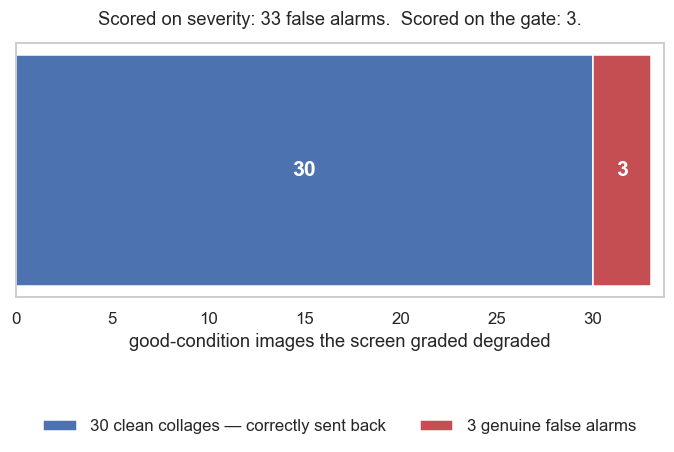

In [8]:
good_rows = {
    name: sum(v for k, v in matrix_.items()
              if k.split("->")[0] == "GOOD" and k.split("->")[1] != "GOOD")
    for name, matrix_ in report["severity_by_composition"].items()
}

fig, ax = plt.subplots(figsize=(7.6, 3.0))
left = 0.0
palette = {"MULTIPLE": "#4c72b0", "SINGLE": "#c44e52"}
labels = {
    "MULTIPLE": f"{good_rows['MULTIPLE']} clean collages — correctly sent back",
    "SINGLE": f"{good_rows['SINGLE']} genuine false alarms",
}
for name in ("MULTIPLE", "SINGLE"):
    ax.barh([0], [good_rows[name]], left=left, color=palette[name], label=labels[name], height=0.5)
    ax.text(left + good_rows[name] / 2, 0, str(good_rows[name]),
            ha="center", va="center", color="white", fontsize=14, weight="bold")
    left += good_rows[name]

ax.set_yticks([])
ax.set_xlim(0, left * 1.02)
ax.set_xlabel("good-condition images the screen graded degraded")
ax.set_title(
    f"Scored on severity: {left:.0f} false alarms.  Scored on the gate: {good_rows['SINGLE']}.",
    pad=12,
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False)
ax.grid(False)
save(fig, "v13_false_alarm_decomposition")
plt.show()

## 4. Severity, whole and split

The severity call is the weaker axis, and the split says why: it is almost
entirely a collage effect. A photograph of four receipts has four separate
tilts and four sets of edges, so a *clean* collage looks damaged to a screen
asking "is this photograph in good condition".

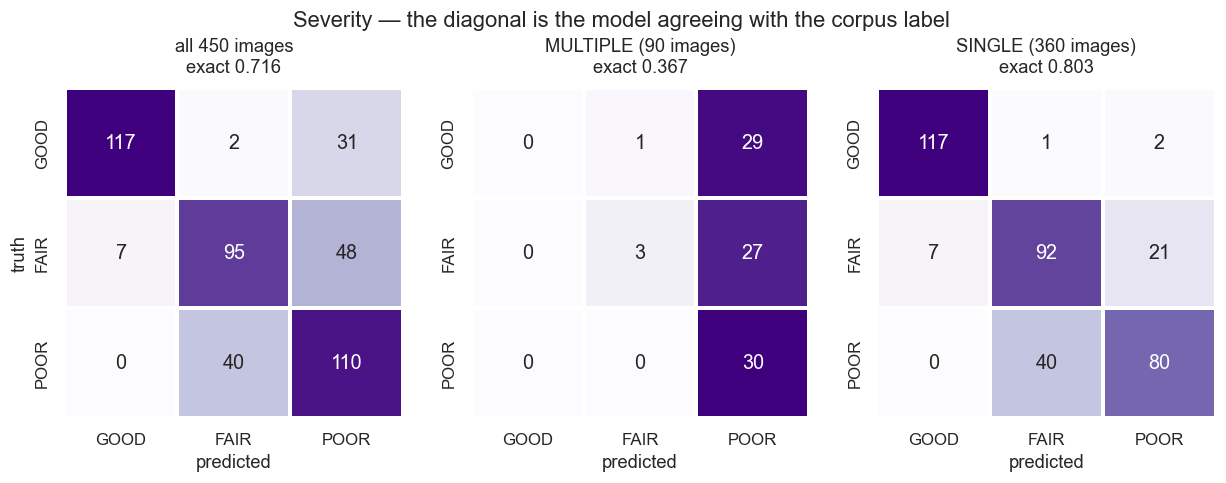

In [9]:
def to_grid(flat: dict) -> pd.DataFrame:
    """Re-key a "truth->predicted" dict into a levels x levels frame."""
    grid_ = pd.DataFrame(0, index=LEVELS, columns=LEVELS)
    for key, count in flat.items():
        truth, predicted = key.split("->")
        grid_.loc[truth, predicted] = count
    return grid_


split = report["severity_by_composition"]
panels = [("all 450 images", to_grid(report["overall_confusion"]))]
panels += [(f"{name} ({sum(m.values())} images)", to_grid(m)) for name, m in split.items()]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
for ax, (title, grid_) in zip(axes, panels, strict=True):
    exact = sum(grid_.loc[level, level] for level in LEVELS) / grid_.to_numpy().sum()
    sns.heatmap(
        grid_, annot=True, fmt="d", cmap="Purples", cbar=False,
        linewidths=1.5, linecolor="white", annot_kws={"size": 13}, ax=ax,
    )
    ax.set_title(f"{title}\nexact {exact:.3f}", pad=10)
    ax.set_xlabel("predicted")
axes[0].set_ylabel("truth")

fig.suptitle("Severity — the diagonal is the model agreeing with the corpus label", y=1.06)
save(fig, "v13_severity_split")
plt.show()

0.803 exact on single documents against 0.367 on collages. The collage column is
not a failure — a clean collage graded POOR is a *correct routing decision*
reached by the other axis — but it is why the whole-corpus severity figure of
0.716 understates the screen. Do not tune against it.

## 5. Per-criterion — the reasons, not the decision

These are the six defect questions. The gate does not read them: it reads
OVERALL and COMPOSITION only. They matter if the screen ever tells a taxpayer
*why* an image came back.

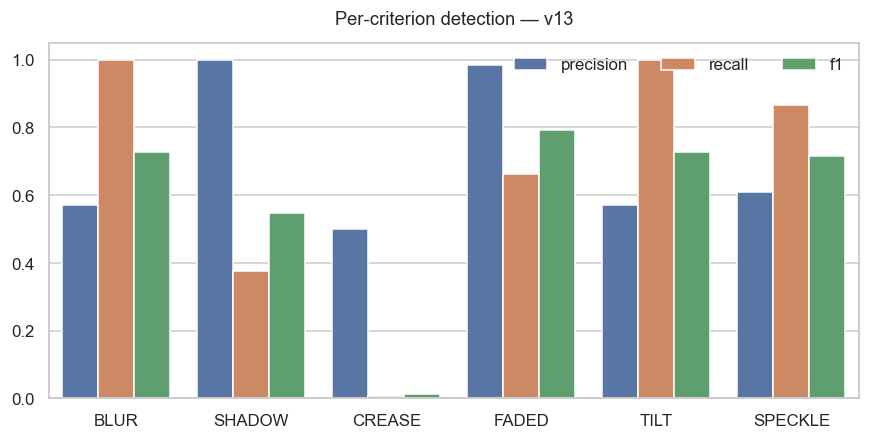

In [10]:
rows = []
for name, values in report["per_criterion"].items():
    for metric in ("precision", "recall", "f1"):
        rows.append({"criterion": name.upper(), "metric": metric, "value": values[metric]})
criteria = pd.DataFrame(rows)
order = [c.upper() for c in report["per_criterion"]]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
sns.barplot(criteria, x="criterion", y="value", hue="metric", order=order, ax=ax)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Per-criterion detection — v13", pad=12)
ax.legend(title="", loc="upper right", ncol=3, frameon=False)
save(fig, "v13_per_criterion")
plt.show()

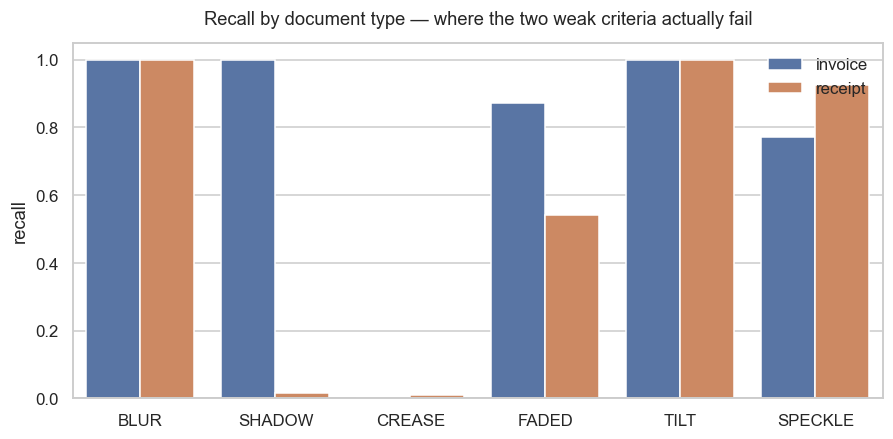

In [11]:
rows = []
for doc_type, criteria_ in report["by_document_type"].items():
    for name, values in criteria_.items():
        rows.append({
            "document type": doc_type,
            "criterion": name.upper(),
            "recall": values["recall"],
        })
by_type = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
sns.barplot(by_type, x="criterion", y="recall", hue="document type", order=order, ax=ax)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_title("Recall by document type — where the two weak criteria actually fail", pad=12)
ax.legend(title="", loc="upper right", frameon=False)
save(fig, "v13_recall_by_document_type")
plt.show()

Two criteria are effectively dead, and the split shows they die for opposite
reasons:

- **SHADOW** is perfect on invoices (recall 1.000) and absent on receipts
  (0.016). It is a receipt-specific failure.
- **CREASE** is near zero on both — 1 true positive against 149 misses. That is
  the finding already recorded in `a99a451`: the crease fix refuted its own
  hypothesis, and CREASE is the model, not the prompt.

Neither affects the gate, because a creased receipt is caught by BLUR, TILT or
SPECKLE instead. They matter only for the stated reason.

## 6. What adding the question did to the other answers

v12 and v13 ran on the same corpus and the same hardware. COMPOSITION is
appended as question 8 without renumbering the seven above it, so the prompt
comment calls it "purely additive". Additive in *structure* — but the other
answers moved anyway.

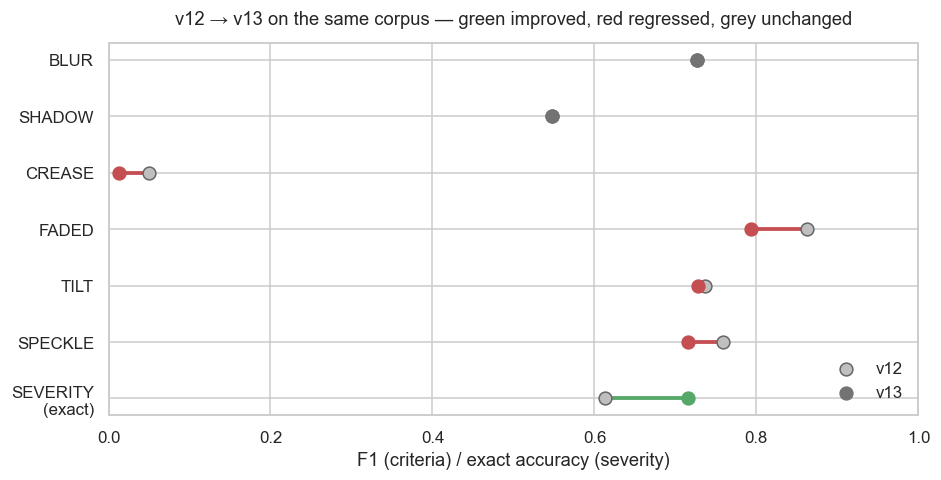

variant              v12    v13  change
criterion                              
BLUR               0.727  0.727   0.000
SHADOW             0.547  0.547   0.000
CREASE             0.050  0.013  -0.037
FADED              0.863  0.793  -0.070
TILT               0.736  0.728  -0.008
SPECKLE            0.759  0.715  -0.044
SEVERITY\n(exact)  0.613  0.716   0.102


In [12]:
# The baseline is the embedded v12 record; the other side is whatever report was
# loaded, not the embedded v13 literal. Point REPORT_PATH at a different run and
# this chart compares THAT run against v12, rather than quietly redrawing the
# embedded figures under a new heading.
BASELINE = V12["variant"].removeprefix("quality_screen_")
CURRENT = report.get("variant", "loaded").removeprefix("quality_screen_")

rows = []
for variant, source in ((BASELINE, V12), (CURRENT, report)):
    for name, values in source["per_criterion"].items():
        rows.append({"criterion": name.upper(), "variant": variant, "f1": values["f1"]})
    exact = sum(
        count for key, count in source["overall_confusion"].items()
        if key.split("->")[0] == key.split("->")[1]
    ) / source["counts"]["total"]
    rows.append({"criterion": "SEVERITY\n(exact)", "variant": variant, "f1": exact})
comparison = pd.DataFrame(rows)
comparison_order = order + ["SEVERITY\n(exact)"]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
wide = comparison.pivot(index="criterion", columns="variant", values="f1").loc[comparison_order]
# A dumbbell rather than paired bars: the movement is the subject here, and
# paired bars make the reader measure two heights to see one difference.
for position, (name, row) in enumerate(wide.iterrows()):
    change = row[CURRENT] - row[BASELINE]
    # Unchanged gets its own colour. Painting a zero-length dumbbell green
    # would claim an improvement that did not happen -- BLUR and SHADOW did
    # not move by a single true positive.
    if abs(change) < 0.001:
        colour = "0.45"
    else:
        colour = "#55a868" if change > 0 else "#c44e52"
    ax.plot([row[BASELINE], row[CURRENT]], [position, position], color=colour, lw=2.5, zorder=1)
    ax.scatter(row[BASELINE], position, s=70, color="0.75", edgecolor="0.4", zorder=2,
               label=BASELINE if position == 0 else "")
    ax.scatter(row[CURRENT], position, s=70, color=colour, zorder=3,
               label=CURRENT if position == 0 else "")

ax.set_yticks(range(len(wide)))
ax.set_yticklabels(wide.index)
ax.invert_yaxis()  # read top-down, in the order the printed report lists them
ax.set_xlim(0, 1.0)
ax.set_xlabel("F1 (criteria) / exact accuracy (severity)")
ax.set_title(
    f"{BASELINE} → {CURRENT} on the same corpus — "
    f"green improved, red regressed, grey unchanged",
    pad=12,
)
ax.legend(loc="lower right", frameon=False)
save(fig, "v12_to_v13_shift")
plt.show()

print(wide.assign(change=lambda d: d[CURRENT] - d[BASELINE]).round(3).to_string())

Severity accuracy rose sharply — 0.613 to 0.716, with `FAIR->FAIR` nearly
doubling from 48 to 95 — while FADED traded 56 true positives for 33 fewer
false ones and SPECKLE lost precision. BLUR and SHADOW did not move at all.

The prompt comment at `prompts/quality_screen.yaml:871` is right that nothing
was renumbered; it is worth recording that the answers still shifted. Adding a
question changes what the model does with the ones before it.

## Findings

1. **The gate works.** 0.991 precision, 0.979 recall, F1 0.985 on the decision
   the pipeline makes. No heavily degraded image passed. This reproduces the
   recorded 0.997 / 0.967 / 0.982 on the sibling corpus.
2. **Collage detection is complete.** 90 of 90, with four folded receipts
   misread as collages — all of which were being sent back anyway.
3. **Severity alone understates the screen** by counting 30 correctly-rejected
   clean collages as false alarms. Score the gate, not the grade.
4. **SHADOW is a receipt-only failure; CREASE is a model limitation.** Neither
   reaches the gate, so neither blocks the pass/fail decision.
5. **Adding question 8 moved answers 1–7.** Severity improved, FADED recall
   fell. Worth knowing before the next variant.

### Not measured here

Whether the four `FOLDED*` errors would be reported to a taxpayer as "several
documents" rather than "creased". The gate is right; the stated reason is not.